In [61]:
# ------------------ IMPORTS ------------------

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.metrics import (
    classification_report,
    f1_score,
    precision_recall_curve,
    average_precision_score,
    brier_score_loss,
    hamming_loss,
    label_ranking_loss,
    coverage_error,
    matthews_corrcoef
)
from sklearn.calibration import calibration_curve

In [62]:
# ------------------ CONFIG ------------------

ROOT = Path.cwd().resolve()
while not (ROOT / "results").exists():
    ROOT = ROOT.parent

FILES = {
    "Classical Mamba": ROOT / "results/classical-mamba/ClassicalMamba_Wafer_Results.json",
    "Hybrid Mamba": ROOT / "results/hybrid-mamba/HybridMamba_Wafer_Results.json",
    "ResNet": ROOT / "results/resnet/Resnet_Wafer_Results.json",
    "Vision Transformer": ROOT / "results/vit/VisionTransformer_Wafer_Results.json",
}


CLASSES = [
    "Center",
    "Donut",
    "Edge_Loc",
    "Edge_Ring",
    "Loc",
    "Near_Full",
    "Scratch",
    "Random",
]

THRESHOLD = 0.5
RARE_CLASS = "Near_Full"


In [63]:
# ------------------ LOAD ------------------

def load(path):
    with open(path) as f:
        d = json.load(f)
    logits = np.array(d["test_data"]["logits"])
    y_true = np.array(d["test_data"]["labels"])
    y_prob = 1 / (1 + np.exp(-logits))
    y_pred = (y_prob >= THRESHOLD).astype(int)
    return y_true, y_prob, y_pred

models = {k: load(v) for k, v in FILES.items()}

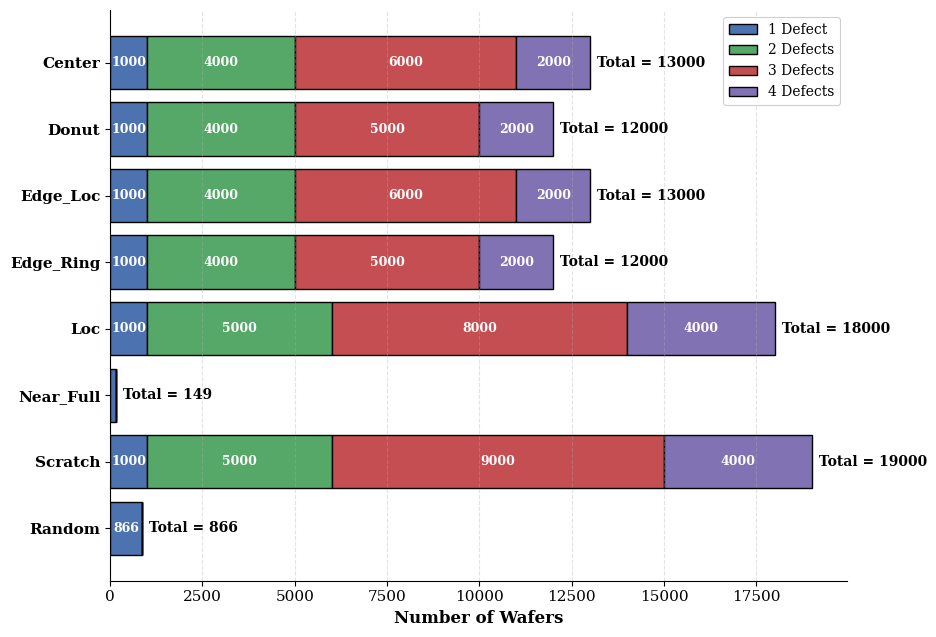

In [87]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- LOAD FULL DATASET (NOT SPLIT) ----------

DATA_PATH = "/home/meow/Documents/wafer-defect-classification/data/Wafer_Map_Datasets.npz"

npz = np.load(DATA_PATH, allow_pickle=True)
X = npz["arr_0"]
Y = npz["arr_1"].astype(int)

CLASSES = [
    "Center", "Donut", "Edge_Loc", "Edge_Ring",
    "Loc", "Near_Full", "Scratch", "Random"
]

# ---------- COMPUTE COMPLEXITY BUCKETS ----------

defect_count = Y.sum(axis=1)

counts = {
    cls: {
        1: 0,
        2: 0,
        3: 0,
        4: 0
    }
    for cls in CLASSES
}

for i, cls in enumerate(CLASSES):
    for k in [1, 2, 3, 4]:
        counts[cls][k] = np.sum((Y[:, i] == 1) & (defect_count == k))

# Convert to arrays
single = np.array([counts[c][1] for c in CLASSES])
double = np.array([counts[c][2] for c in CLASSES])
triple = np.array([counts[c][3] for c in CLASSES])
quad   = np.array([counts[c][4] for c in CLASSES])

total = single + double + triple + quad

# ---------- COLORS (PAPER FRIENDLY) ----------

COLORS = {
    1: "#4C72B0",  # blue
    2: "#55A868",  # green
    3: "#C44E52",  # red
    4: "#8172B3",  # purple
}

# ---------- PLOT ----------

fig, ax = plt.subplots(figsize=(9.5, 6.5))

y = np.arange(len(CLASSES))

b1 = ax.barh(y, single, color=COLORS[1], edgecolor="black", label="1 Defect")
b2 = ax.barh(y, double, left=single, color=COLORS[2], edgecolor="black", label="2 Defects")
b3 = ax.barh(y, triple, left=single+double, color=COLORS[3], edgecolor="black", label="3 Defects")
b4 = ax.barh(y, quad,   left=single+double+triple, color=COLORS[4], edgecolor="black", label="4 Defects")

# ---------- NUMBER ANNOTATIONS INSIDE BARS ----------

def annotate(bars, values, left_offset):
    for i, (bar, v, left) in enumerate(zip(bars, values, left_offset)):
        cls = CLASSES[i]

        # Skip Near_Full only (too small, clutters figure)
        if cls == "Near_Full":
            continue

        if v > 0:
            ax.text(
                left + v / 2,
                bar.get_y() + bar.get_height() / 2,
                f"{v}",
                ha="center",
                va="center",
                fontsize=9,
                fontweight="bold",
                color="white"
            )


annotate(b1, single, np.zeros_like(single))
annotate(b2, double, single)
annotate(b3, triple, single + double)
annotate(b4, quad,   single + double + triple)

# ---------- TOTAL ABOVE EACH BAR ----------

for i, t in enumerate(total):
    ax.text(
        t + max(total)*0.01,
        i,
        f"Total = {t}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

# ---------- AXES STYLING ----------

ax.set_yticks(y)
ax.set_yticklabels(CLASSES, fontsize=11, fontweight="bold")

ax.set_xlabel("Number of Wafers", fontsize=12, fontweight="bold")
# ax.set_title("WM38K Multilabel Distribution: Defect Occurrence by Complexity", fontsize=14, fontweight="bold", pad=12)

ax.invert_yaxis()

# Grid (clean academic style)
ax.grid(axis="x", linestyle="--", alpha=0.35)

# Legend
leg = ax.legend(
    frameon=True,
    fontsize=10,
    loc="upper right"
)
leg.get_frame().set_alpha(0.95)
leg.get_frame().set_linewidth(0.8)

# Remove top/right spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
fname = "defect_distribution.png"
plt.savefig(fname, dpi=300, bbox_inches="tight")
plt.show()


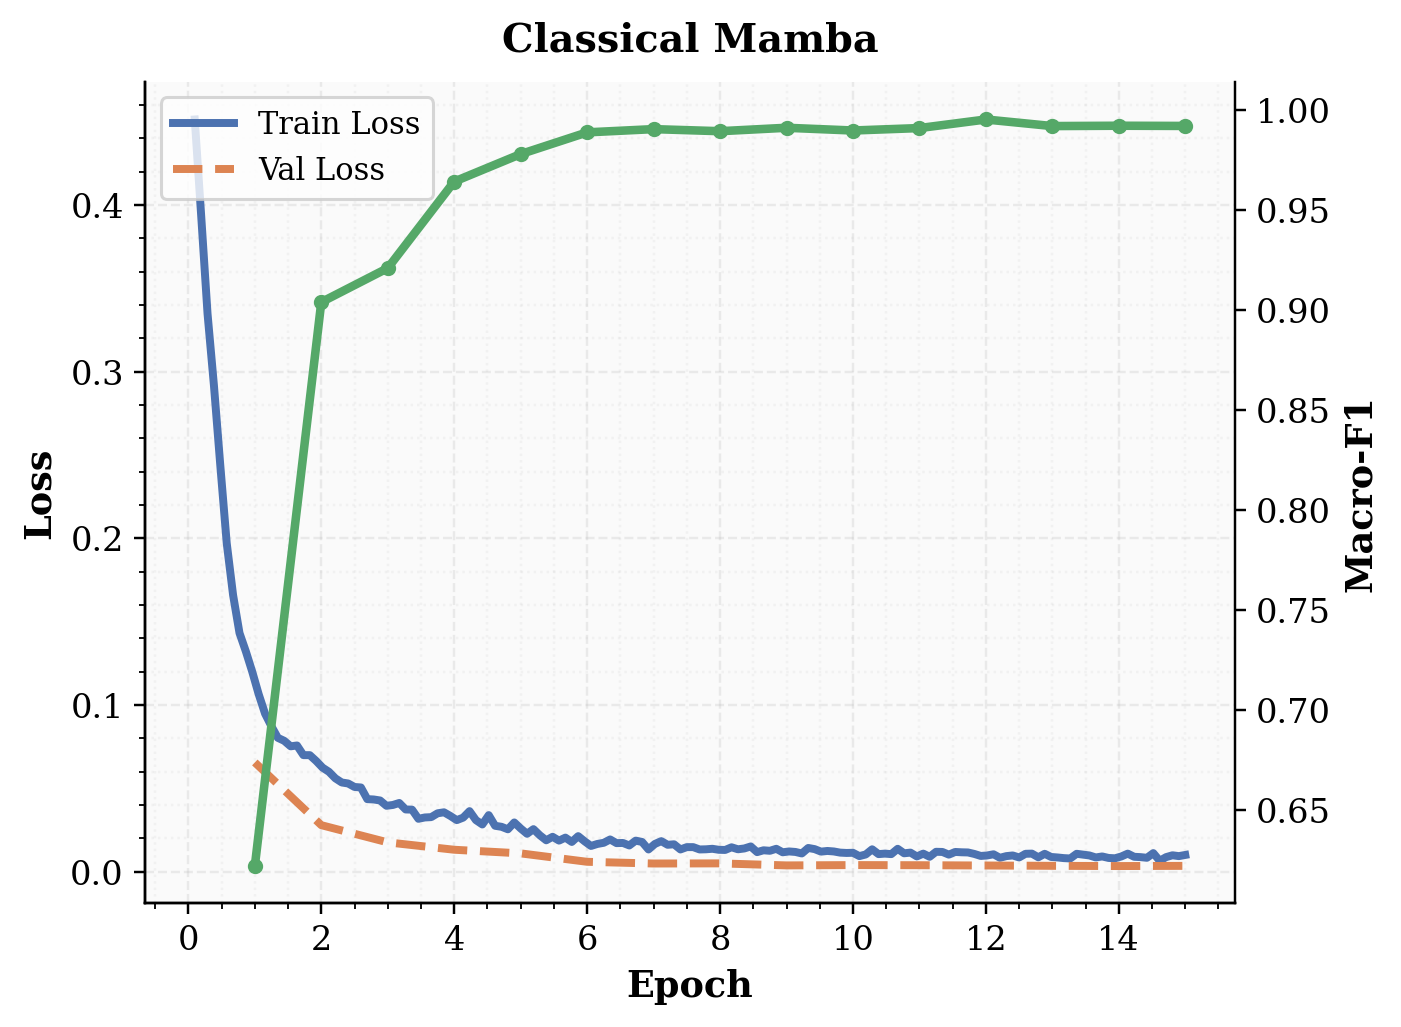

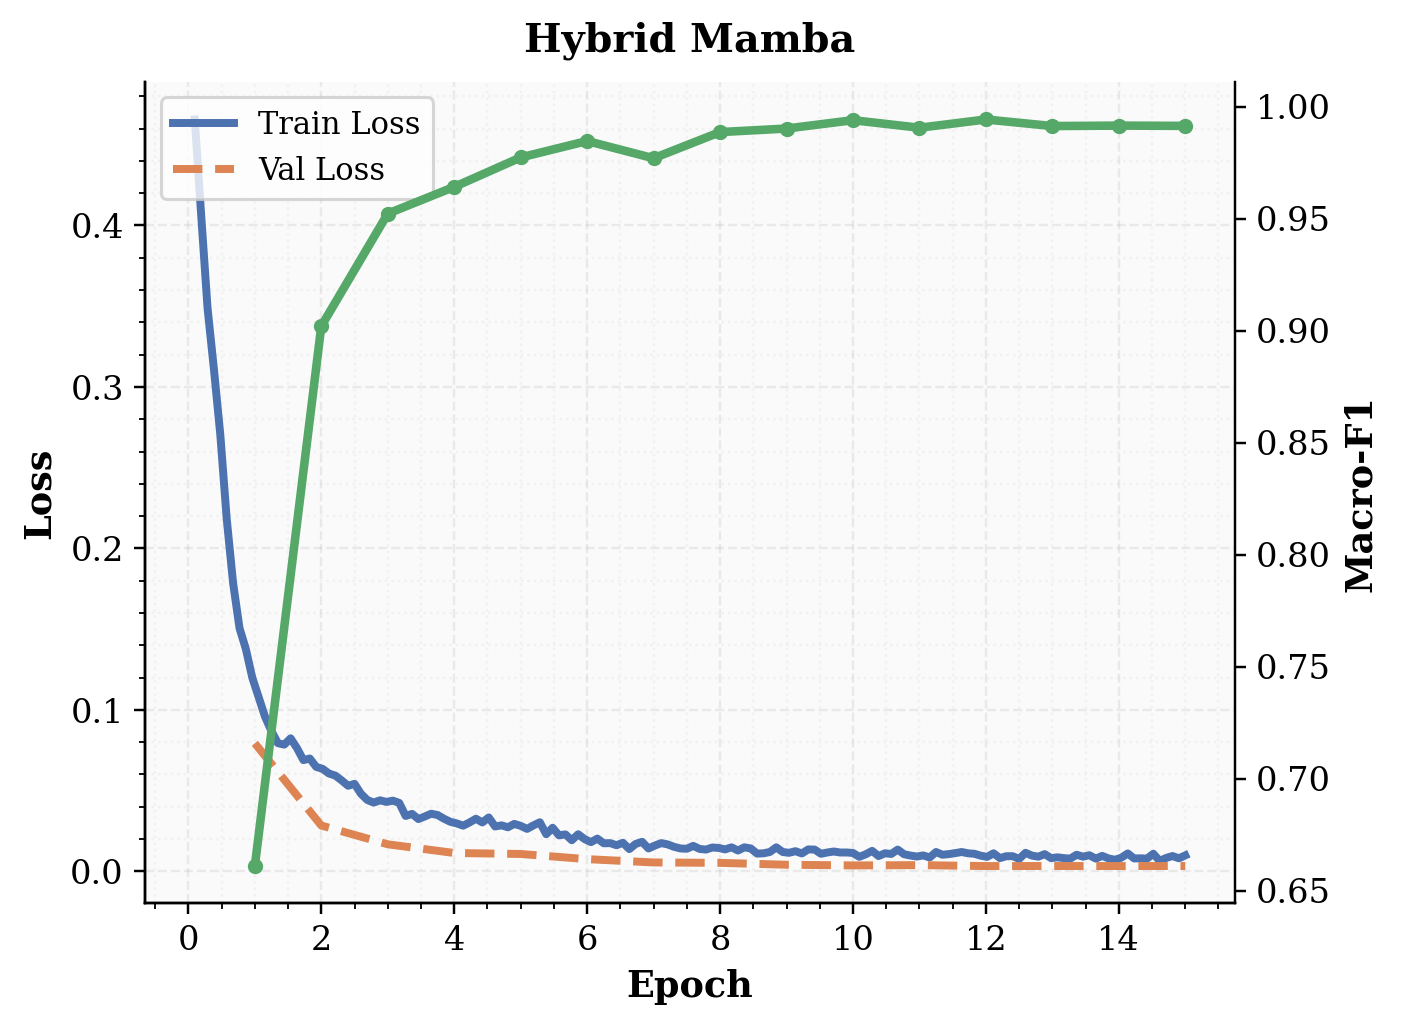

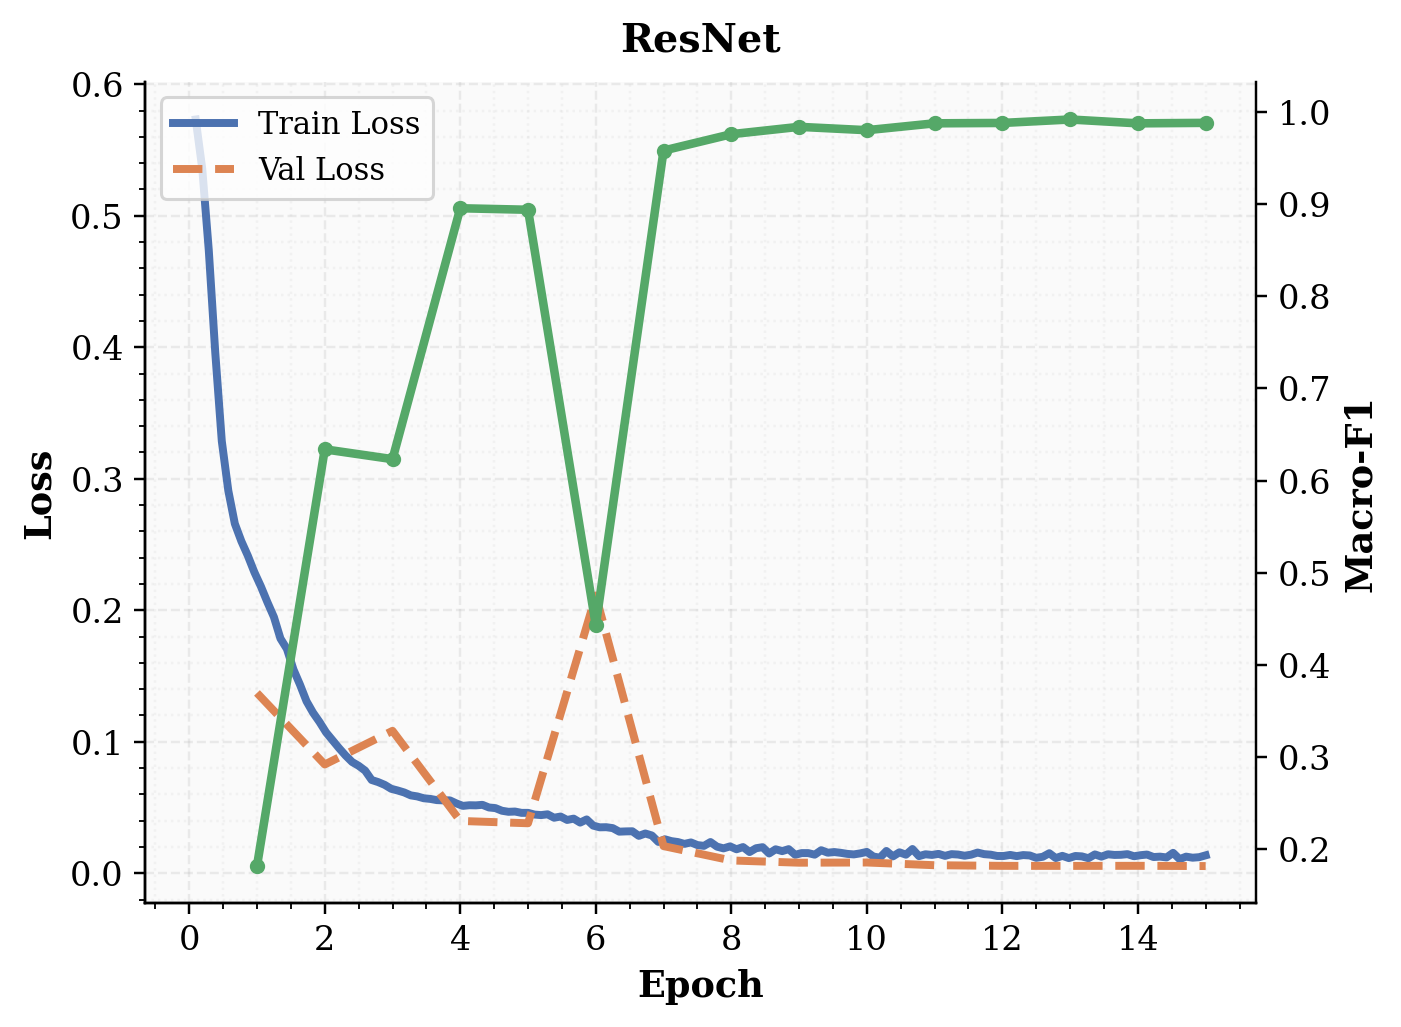

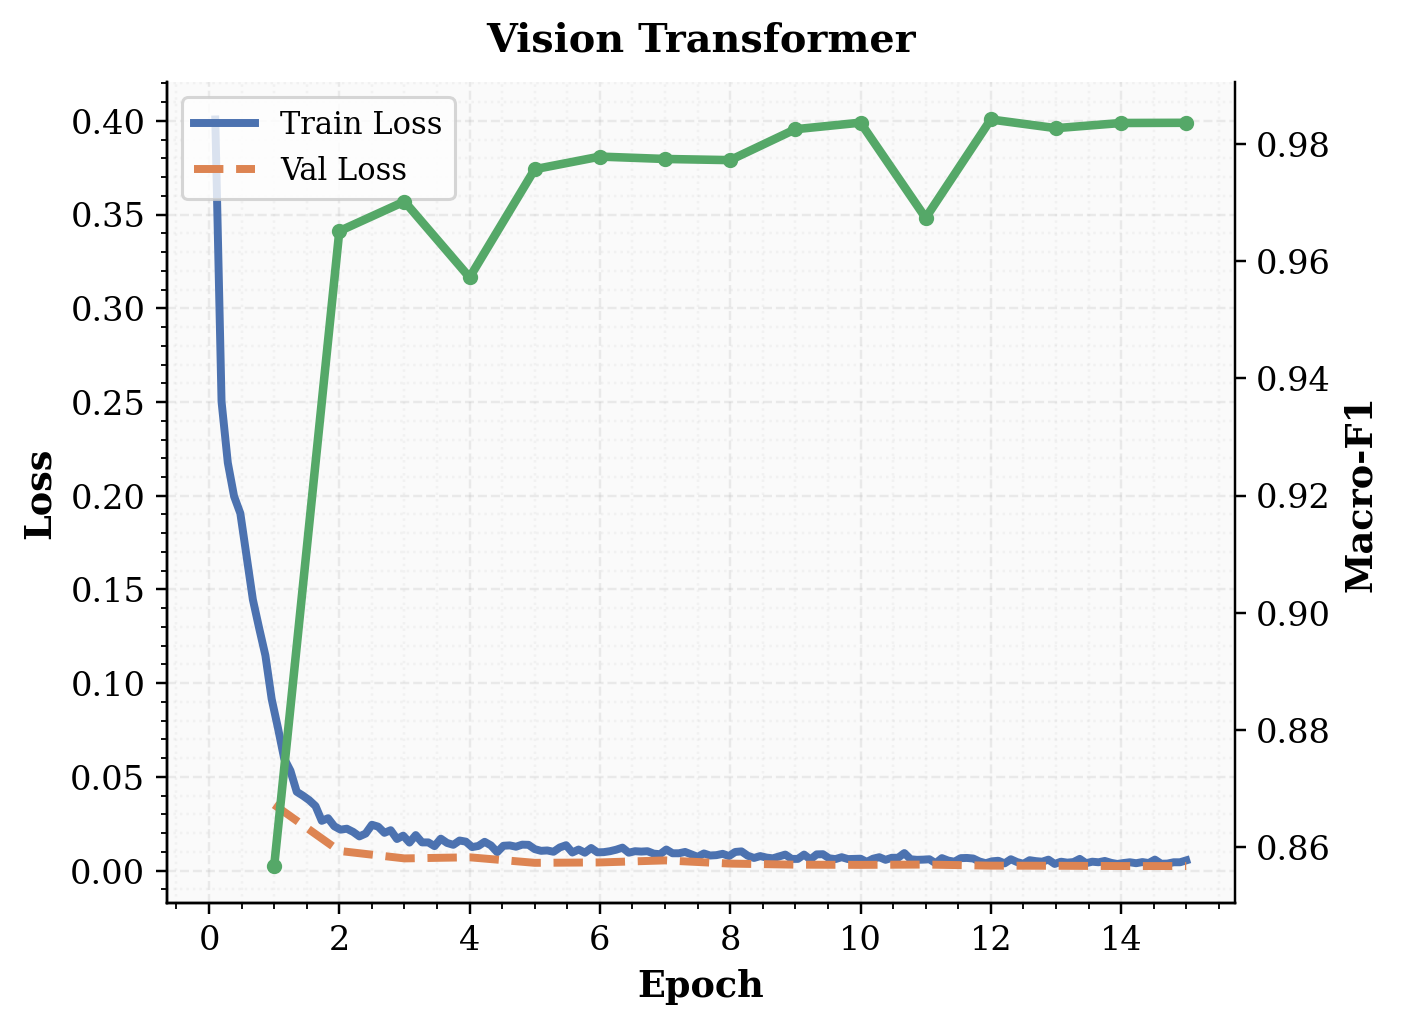

In [86]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

# ------------------ LOAD LOGS ------------------

def load_logs(path):
    with open(path) as f:
        return json.load(f)["training_logs"]

logs = {name: load_logs(Path(p)) for name, p in FILES.items()}

def extract_curve(logs, key):
    xs, ys = [], []
    for entry in logs:
        if key in entry:
            xs.append(entry["epoch"])
            ys.append(entry[key])
    return np.array(xs), np.array(ys)

curves = {
    name: {
        "train_loss": extract_curve(l, "loss"),
        "val_loss": extract_curve(l, "eval_loss"),
        "val_f1": extract_curve(l, "eval_macro_f1"),
    }
    for name, l in logs.items()
}

# ------------------ STYLE ------------------

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
})

COLORS = {
    "train": "#4C72B0",
    "val": "#DD8452",
    "f1": "#55A868",
}

MODEL_COLORS = {
    "Classical Mamba": "#4C72B0",
    "Hybrid Mamba": "#C44E52",
    "ResNet": "#55A868",
    "Vision Transformer": "#8172B3",
}

# ------------------ PLOT EACH MODEL SEPARATELY ------------------

for name, c in curves.items():

    fig, ax = plt.subplots(figsize=(6.5, 4.8), dpi=220)
    ax2 = ax.twinx()

    ax.set_facecolor("#FAFAFA")

    # -------- LOSS CURVES --------
    l1, = ax.plot(
        *c["train_loss"],
        color=COLORS["train"],
        linewidth=2.6,
        label="Train Loss"
    )

    l2, = ax.plot(
        *c["val_loss"],
        color=COLORS["val"],
        linestyle="--",
        linewidth=2.6,
        label="Val Loss"
    )

    # -------- F1 CURVE --------
    l3, = ax2.plot(
        *c["val_f1"],
        color=COLORS["f1"],
        marker="o",
        linewidth=2.8,
        markersize=4,
        label="Val Macro-F1",
        zorder=3
    )

    # -------- LABELS --------
    ax.set_xlabel("Epoch", fontweight="bold")
    ax.set_ylabel("Loss", fontweight="bold")
    ax2.set_ylabel("Macro-F1", fontweight="bold")

    ax.set_title(
        name,
        fontweight="bold",
        pad=10
    )

    # -------- LOCAL LEGENDS --------
    ax.legend(
        handles=[l1, l2],
        loc="upper left",
        frameon=True,
        fontsize=10
    )


    # -------- CLEAN SPINES --------
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    ax2.spines["top"].set_visible(False)

    # -------- GRID --------
    ax.grid(True, which="major", linestyle="--", alpha=0.22)
    ax.grid(True, which="minor", linestyle=":", alpha=0.12)
    ax.minorticks_on()

    plt.tight_layout()

    fname = f"training_dynamics_{name.replace(' ', '_')}.png"
    plt.savefig(fname, dpi=300, bbox_inches="tight")
    plt.show()


In [82]:
import numpy as np
import pandas as pd

# ------------------ CALIBRATION HELPERS ------------------

def expected_calibration_error(y_true, y_prob, bins=15):
    ece = 0.0
    for c in range(y_true.shape[1]):
        prob = y_prob[:, c]
        true = y_true[:, c]
        bins_edges = np.linspace(0, 1, bins + 1)

        for i in range(bins):
            mask = (prob >= bins_edges[i]) & (prob < bins_edges[i+1])
            if mask.sum() == 0:
                continue
            acc = true[mask].mean()
            conf = prob[mask].mean()
            ece += (mask.sum() / len(prob)) * abs(acc - conf)

    return ece / y_true.shape[1]


def max_calibration_error(y_true, y_prob, bins=15):
    mce = 0.0
    for c in range(y_true.shape[1]):
        prob = y_prob[:, c]
        true = y_true[:, c]
        bins_edges = np.linspace(0, 1, bins + 1)

        for i in range(bins):
            mask = (prob >= bins_edges[i]) & (prob < bins_edges[i+1])
            if mask.sum() == 0:
                continue
            acc = true[mask].mean()
            conf = prob[mask].mean()
            mce = max(mce, abs(acc - conf))

    return mce


def brier_score(y_true, y_prob):
    return np.mean((y_prob - y_true) ** 2)


def negative_log_likelihood(y_true, y_prob, eps=1e-8):
    y_prob = np.clip(y_prob, eps, 1 - eps)
    return -np.mean(
        y_true * np.log(y_prob) + (1 - y_true) * np.log(1 - y_prob)
    )


def accuracy_at_high_confidence(y_true, y_prob, threshold=0.9):
    conf = np.max(y_prob, axis=1)
    preds = (y_prob >= 0.5).astype(int)
    correct = (preds == y_true).all(axis=1)

    mask = conf >= threshold
    return correct[mask].mean() if mask.any() else np.nan


# ------------------ CALIBRATION TABLE ------------------

rows = []

for name, (y_true, y_prob, _) in models.items():
    rows.append({
        "Model": name,
        "ECE ↓": expected_calibration_error(y_true, y_prob),
        "MCE ↓": max_calibration_error(y_true, y_prob),
        "Brier ↓": brier_score(y_true, y_prob),
        "NLL ↓": negative_log_likelihood(y_true, y_prob),
        "Acc@Conf≥0.9 ↑": accuracy_at_high_confidence(y_true, y_prob),
    })

df_calibration = pd.DataFrame(rows)

print("\nCALIBRATION METRICS (TOP-5, NUMERIC ONLY)\n")
print(df_calibration.round(4).to_string(index=False))



CALIBRATION METRICS (TOP-5, NUMERIC ONLY)

             Model  ECE ↓  MCE ↓  Brier ↓  NLL ↓  Acc@Conf≥0.9 ↑
   Classical Mamba 0.0398 0.6597   0.0064 0.0502          0.9709
      Hybrid Mamba 0.0407 0.5553   0.0063 0.0503          0.9749
            ResNet 0.0554 0.5623   0.0118 0.0723          0.9478
Vision Transformer 0.0475 0.6204   0.0070 0.0578          0.9727


In [67]:
import pandas as pd
from sklearn.metrics import recall_score, f1_score

CLASSES = [
    "Center", "Donut", "Edge_Loc", "Edge_Ring",
    "Loc", "Near_Full", "Scratch", "Random"
]

MODEL_ORDER = [
    "Classical Mamba",
    "Hybrid Mamba",
    "ResNet",
    "Vision Transformer"
]

rows = []

for i, cls in enumerate(CLASSES):
    row = {"Class": cls}

    for model in MODEL_ORDER:
        y_true, _, y_pred = models[model]

        row[("Recall", model)] = recall_score(
            y_true[:, i],
            y_pred[:, i],
            zero_division=0
        )

        row[("Macro-F1", model)] = f1_score(
            y_true[:, i],
            y_pred[:, i],
            zero_division=0
        )

    rows.append(row)

df = pd.DataFrame(rows).set_index("Class")

df.columns = pd.MultiIndex.from_tuples(df.columns)
df = df.sort_index(axis=1, level=0)

print("\nPER-CLASS SINGLE-DEFECT PERFORMANCE (RECALL & MACRO-F1)\n")
print(df.round(4).to_string())



PER-CLASS SINGLE-DEFECT PERFORMANCE (RECALL & MACRO-F1)

                 Macro-F1                                                  Recall                                        
          Classical Mamba Hybrid Mamba  ResNet Vision Transformer Classical Mamba Hybrid Mamba  ResNet Vision Transformer
Class                                                                                                                    
Center             0.9986       0.9994  1.0000             1.0000          0.9981       0.9988  1.0000             1.0000
Donut              1.0000       1.0000  1.0000             1.0000          1.0000       1.0000  1.0000             1.0000
Edge_Loc           0.9894       0.9888  0.9686             0.9884          0.9839       0.9839  0.9531             0.9831
Edge_Ring          0.9930       0.9941  0.9926             0.9941          0.9975       0.9975  0.9975             0.9983
Loc                0.9923       0.9933  0.9879             0.9919          0.9863       

In [68]:
import pandas as pd
from sklearn.metrics import f1_score

MODEL_ORDER = [
    "Classical Mamba",
    "Hybrid Mamba",
    "ResNet",
    "Vision Transformer"
]

def subset_accuracy(y_true, y_pred):
    return (y_true == y_pred).all(axis=1).mean()

rows = []

for k in [1, 2, 3, 4]:
    row = {"Defect Complexity": f"{k} Defect" if k == 1 else f"{k} Defects"}

    for model in MODEL_ORDER:
        y_true, _, y_pred = models[model]

        mask = y_true.sum(axis=1) == k
        if mask.sum() == 0:
            row[(model, "Macro-F1")] = None
            row[(model, "SubsetAcc")] = None
            continue

        row[(model, "Macro-F1")] = f1_score(
            y_true[mask],
            y_pred[mask],
            average="macro",
            zero_division=0
        )

        row[(model, "SubsetAcc")] = subset_accuracy(
            y_true[mask],
            y_pred[mask]
        )

    rows.append(row)

df = pd.DataFrame(rows).set_index("Defect Complexity")

df.columns = pd.MultiIndex.from_tuples(df.columns)
df = df.sort_index(axis=1, level=0)

print("\nDEFECT COMPLEXITY PERFORMANCE (MACRO-F1 & SUBSET ACCURACY)\n")
print(df.round(4).to_string())



DEFECT COMPLEXITY PERFORMANCE (MACRO-F1 & SUBSET ACCURACY)

                  Classical Mamba           Hybrid Mamba             ResNet           Vision Transformer          
                         Macro-F1 SubsetAcc     Macro-F1 SubsetAcc Macro-F1 SubsetAcc           Macro-F1 SubsetAcc
Defect Complexity                                                                                                 
1 Defect                   0.9791    0.9882       0.9812    0.9854   0.9714    0.9777             0.9793    0.9840
2 Defects                  0.7462    0.9812       0.7466    0.9831   0.7437    0.9662             0.7461    0.9804
3 Defects                  0.7443    0.9587       0.7446    0.9634   0.7407    0.9302             0.7453    0.9638
4 Defects                  0.7439    0.9312       0.7458    0.9478   0.7372    0.8713             0.7441    0.9478


In [69]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    average_precision_score,
    hamming_loss,
    label_ranking_loss,
    coverage_error
)
from scipy.stats import kendalltau

MODEL_ORDER = [
    "Classical Mamba",
    "Hybrid Mamba",
    "ResNet",
    "Vision Transformer"
]

def mean_kendall_tau(y_prob):
    taus = []
    for i in range(1000):
        a = y_prob[i]
        b = a + np.random.normal(0, 1e-4, size=a.shape)
        tau, _ = kendalltau(a, b)
        if not np.isnan(tau):
            taus.append(tau)
    return float(np.mean(taus))

rows = []

for model in MODEL_ORDER:
    y_true, y_prob, y_pred = models[model]

    row = {
        "Model": model,
        "mAP": average_precision_score(y_true, y_prob, average="macro"),
        "Hamming Loss": hamming_loss(y_true, y_pred),
        "Ranking Loss": label_ranking_loss(y_true, y_prob),
        "Coverage Error": coverage_error(y_true, y_prob),
        "Kendall τ": mean_kendall_tau(y_prob)
    }

    rows.append(row)

df = pd.DataFrame(rows)

print("\nADVANCED MULTILABEL QUALITY METRICS\n")
print(df.round(5).to_string(index=False))



ADVANCED MULTILABEL QUALITY METRICS

             Model     mAP  Hamming Loss  Ranking Loss  Coverage Error  Kendall τ
   Classical Mamba 0.99595       0.00437       0.00069         2.30786    0.99830
      Hybrid Mamba 0.99727       0.00388       0.00056         2.30615    0.99841
            ResNet 0.99450       0.00723       0.00097         2.31115    0.99911
Vision Transformer 0.99549       0.00404       0.00056         2.30629    0.99816


In [70]:
import numpy as np
import pandas as pd

MODEL_ORDER = [
    "Classical Mamba",
    "Hybrid Mamba",
    "ResNet",
    "Vision Transformer"
]

def entropy(p, eps=1e-12):
    p = np.clip(p, eps, 1 - eps)
    return -(p * np.log(p) + (1 - p) * np.log(1 - p))

rows = []

for model in MODEL_ORDER:
    y_true, y_prob, y_pred = models[model]

    tp_mask = (y_true == 1) & (y_pred == 1)
    fp_mask = (y_true == 0) & (y_pred == 1)

    conf_tp = y_prob[tp_mask].mean()
    conf_fp = y_prob[fp_mask].mean()

    margin = conf_tp - conf_fp

    ent = entropy(y_prob).mean()

    ambiguous = np.mean((y_prob > 0.45) & (y_prob < 0.55))

    rows.append({
        "Model": model,
        "Conf(TP) ↑": conf_tp,
        "Conf(FP) ↓": conf_fp,
        "Margin ↑": margin,
        "Entropy ↓": ent,
        "Ambiguous % ↓": ambiguous * 100
    })

df_conf = pd.DataFrame(rows)

print("\nCONFIDENCE QUALITY & DECISION SHARPNESS\n")
print(df_conf.round(5).to_string(index=False))



CONFIDENCE QUALITY & DECISION SHARPNESS

             Model  Conf(TP) ↑  Conf(FP) ↓  Margin ↑  Entropy ↓  Ambiguous % ↓
   Classical Mamba     0.95845     0.66179   0.29665    0.15380        0.15288
      Hybrid Mamba     0.95825     0.66280   0.29545    0.15499        0.12987
            ResNet     0.93627     0.66140   0.27487    0.19077        0.31562
Vision Transformer     0.95006     0.65199   0.29807    0.18035        0.12822


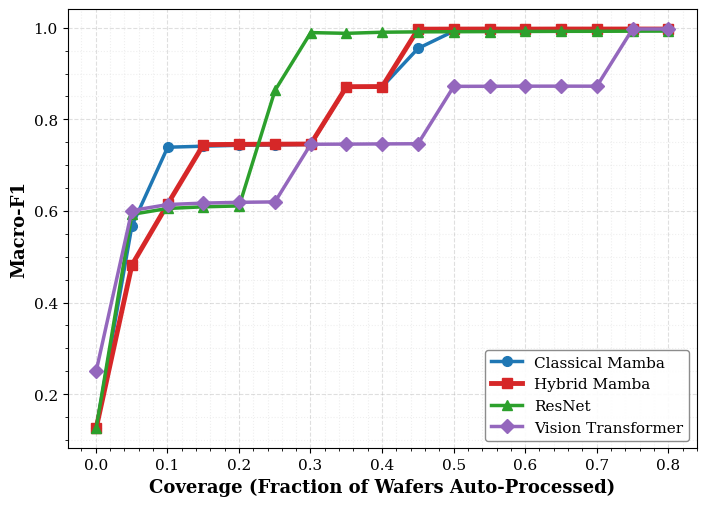

In [89]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

plt.figure(figsize=(7.2, 5.2))

STYLE = {
    "Classical Mamba": dict(color="#1f77b4", marker="o", linewidth=2.5),
    "Hybrid Mamba": dict(color="#d62728", marker="s", linewidth=3.5),   # highlight
    "ResNet": dict(color="#2ca02c", marker="^", linewidth=2.5),
    "Vision Transformer": dict(color="#9467bd", marker="D", linewidth=2.5),
}

for name, (y_true, y_prob, y_pred) in models.items():

    conf = np.zeros(len(y_prob))
    for i in range(len(y_prob)):
        if y_pred[i].sum() > 0:
            conf[i] = y_prob[i][y_pred[i] == 1].min()
        else:
            conf[i] = y_prob[i].max()

    order = np.argsort(conf)

    coverages, scores = [], []

    for k in range(int(0.2 * len(conf)), len(conf), int(0.05 * len(conf))):
        keep = order[k:]

        coverages.append(len(keep) / len(conf))
        scores.append(
            f1_score(
                y_true[keep],
                y_pred[keep],
                average="macro",
                zero_division=0
            )
        )

    plt.plot(
        coverages,
        scores,
        label=name,
        markersize=7,
        **STYLE[name]
    )

# ---- AXIS STYLING ----
plt.xlabel(
    "Coverage (Fraction of Wafers Auto-Processed)",
    fontsize=13,
    fontweight="bold"
)
plt.ylabel(
    "Macro-F1",
    fontsize=13,
    fontweight="bold"
)

# plt.title("Selective Prediction Curve (Production Deployment)",fontsize=14,fontweight="bold",pad=10)

# ---- GRID & BACKGROUND ----
plt.grid(True, which="major", linestyle="--", alpha=0.4)
plt.grid(True, which="minor", linestyle=":", alpha=0.2)
plt.minorticks_on()

# ---- LEGEND ----
plt.legend(
    fontsize=11,
    frameon=True,
    fancybox=True,
    framealpha=0.9,
    edgecolor="gray",
    loc="lower right"
)

# ---- TICKS ----
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

# ---- FINAL LAYOUT ----
plt.tight_layout()
fname = "selective_prediction_curve.png"
plt.savefig(fname, dpi=300, bbox_inches="tight")
plt.show()


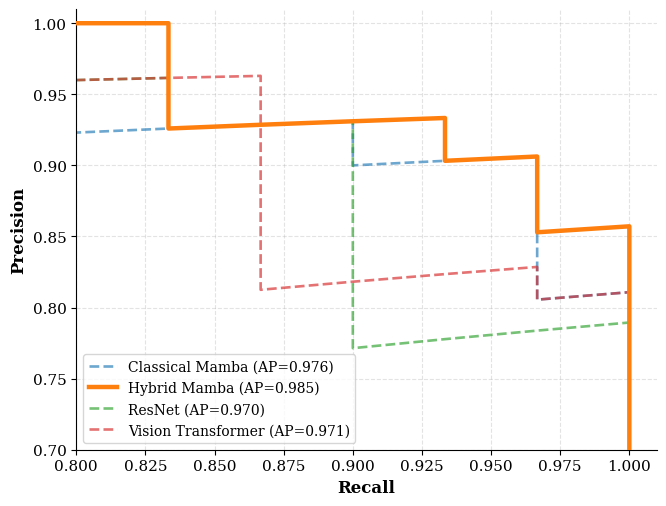

In [90]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

cls_name = "Near_Full"
i = CLASSES.index(cls_name)

plt.figure(figsize=(6.8, 5.2))

for name, (y_true, y_prob, _) in models.items():

    p, r, _ = precision_recall_curve(y_true[:, i], y_prob[:, i])
    ap = average_precision_score(y_true[:, i], y_prob[:, i])

    if name == "Hybrid Mamba":
        plt.plot(
            r, p,
            linewidth=3.2,
            label=f"{name} (AP={ap:.3f})",
            zorder=3
        )
    else:
        plt.plot(
            r, p,
            linestyle="--",
            linewidth=1.9,
            alpha=0.65,
            label=f"{name} (AP={ap:.3f})",
            zorder=2
        )

plt.xlim(0.80, 1.01)
plt.ylim(0.70, 1.01)

plt.xlabel("Recall", fontsize=12, fontweight="bold")
plt.ylabel("Precision", fontsize=12, fontweight="bold")

# plt.title(f"Zoomed Precision–Recall Curve ({cls_name})", fontsize=14, fontweight="bold", pad=12)


plt.legend(frameon=True, fontsize=10, loc="lower left")
plt.grid(True, linestyle="--", alpha=0.35)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
fname = "near_full_precision_recall_curve.png"
plt.savefig(fname, dpi=300, bbox_inches="tight")
plt.show()


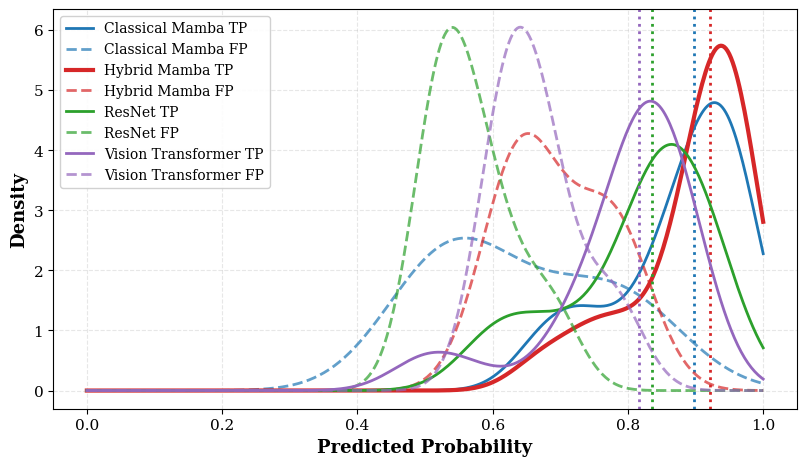

In [96]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

cls_idx = CLASSES.index("Near_Full")

STYLE = {
    "Classical Mamba": "#1f77b4",
    "Hybrid Mamba": "#d62728",
    "ResNet": "#2ca02c",
    "Vision Transformer": "#9467bd",
}

plt.figure(figsize=(8.2, 4.8))

xs = np.linspace(0, 1, 400)

for name, (y_true, y_prob, y_pred) in models.items():
    tp = y_prob[:, cls_idx][(y_true[:, cls_idx] == 1) & (y_pred[:, cls_idx] == 1)]
    fp = y_prob[:, cls_idx][(y_true[:, cls_idx] == 0) & (y_pred[:, cls_idx] == 1)]

    if len(tp) > 0:
        kde_tp = gaussian_kde(tp)
        plt.plot(xs, kde_tp(xs),
                 color=STYLE[name],
                 linewidth=3 if name == "Hybrid Mamba" else 2,
                 label=f"{name} TP")

        plt.axvline(
            np.median(tp),
            color=STYLE[name],
            linestyle=":",
            linewidth=2
        )

    if len(fp) > 0:
        kde_fp = gaussian_kde(fp)
        plt.plot(xs, kde_fp(xs),
                 color=STYLE[name],
                 linestyle="--",
                 alpha=0.7,
                 linewidth=2,
                 label=f"{name} FP")

# ---- AXES ----
plt.xlabel("Predicted Probability", fontsize=13, fontweight="bold")
plt.ylabel("Density", fontsize=13, fontweight="bold")

#Rare Defect (Near_Full) Confidence Separation\nTrue Positives vs False Positives",

# ---- GRID ----
plt.grid(True, linestyle="--", alpha=0.3)

# ---- LEGEND ----
plt.legend(
    fontsize=10,
    ncol=1,
    frameon=True,
    fancybox=True,
    framealpha=0.9
)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
fname = "rare_defect_confidence_separation_near_full_truepositive_vs_falsepositive.png"
plt.savefig(fname, dpi=300, bbox_inches="tight")
plt.show()


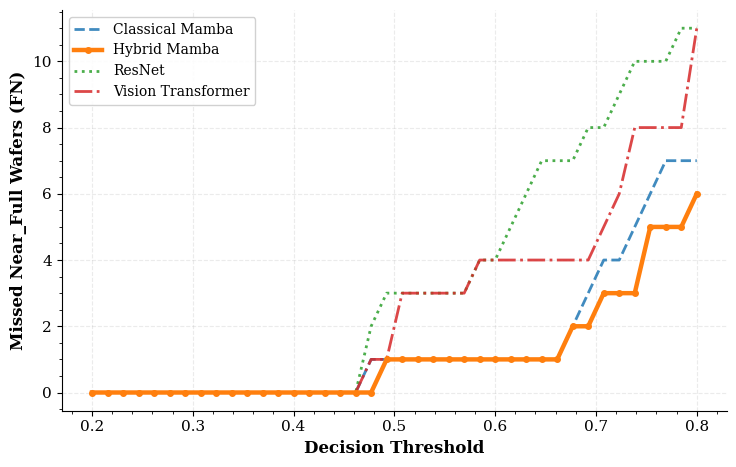

In [91]:
cls_name = "Near_Full"
i = CLASSES.index(cls_name)

plt.figure(figsize=(7.5, 4.8))

LINESTYLES = {
    "Hybrid Mamba": ("-", 3.2, 1.0),
    "Classical Mamba": ("--", 2.0, 0.85),
    "Vision Transformer": ("-.", 2.0, 0.85),
    "ResNet": (":", 2.0, 0.85),
}

for name, (y_true, y_prob, _) in models.items():
    misses = []

    for t in ts:
        y_p = (y_prob[:, i] >= t).astype(int)
        fn = ((y_true[:, i] == 1) & (y_p == 0)).sum()
        misses.append(fn)

    ls, lw, a = LINESTYLES.get(name, ("--", 2.0, 0.8))

    plt.plot(
        ts, misses,
        linestyle=ls,
        linewidth=lw,
        alpha=a,
        marker="o" if name == "Hybrid Mamba" else None,
        markersize=4 if name == "Hybrid Mamba" else 0,
        label=name,
        zorder=3 if name == "Hybrid Mamba" else 2
    )

plt.xlabel("Decision Threshold", fontsize=12, fontweight="bold")
plt.ylabel("Missed Near_Full Wafers (FN)", fontsize=12, fontweight="bold")
# plt.title("Catastrophic Miss Rate vs Decision Threshold (Near_Full)",fontsize=13, fontweight="bold")

plt.grid(True, which="major", linestyle="--", alpha=0.25)
plt.minorticks_on()

leg = plt.legend(frameon=True, fontsize=10, loc="upper left")
leg.get_frame().set_alpha(0.9)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
fname = "catastrophic_miss_rate_vs_decision_threshold_near_full.png"
plt.savefig(fname, dpi=300, bbox_inches="tight")
plt.show()

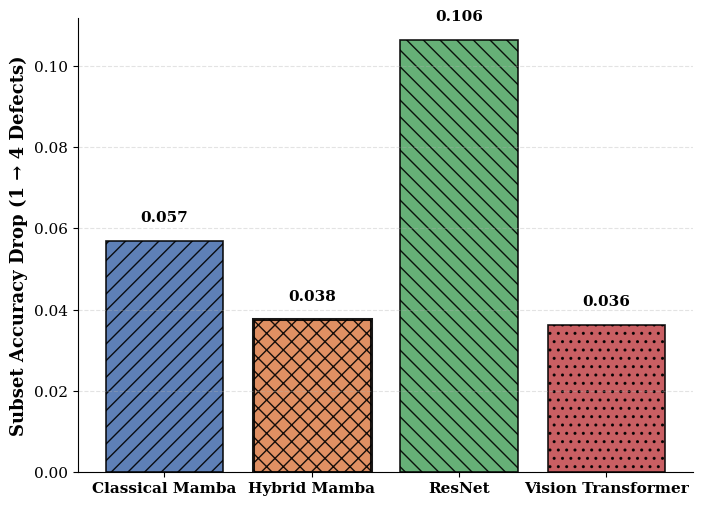

In [92]:
import matplotlib.pyplot as plt
import numpy as np

def subset_accuracy(y_true, y_pred):
    return (y_true == y_pred).all(axis=1).mean()

drops = {}

for name, (y_true, _, y_pred) in models.items():
    acc_1 = subset_accuracy(
        y_true[y_true.sum(axis=1) == 1],
        y_pred[y_true.sum(axis=1) == 1]
    )
    acc_4 = subset_accuracy(
        y_true[y_true.sum(axis=1) == 4],
        y_pred[y_true.sum(axis=1) == 4]
    )
    drops[name] = acc_1 - acc_4

names = list(drops.keys())
values = list(drops.values())

COLORS = {
    "Classical Mamba": "#4C72B0",
    "Hybrid Mamba": "#DD8452",
    "ResNet": "#55A868",
    "Vision Transformer": "#C44E52",
}

HATCH = {
    "Classical Mamba": "//",
    "Hybrid Mamba": "xx",
    "ResNet": "\\\\",
    "Vision Transformer": "..",
}

plt.figure(figsize=(7.2, 5.2))

bars = plt.bar(
    names,
    values,
    color=[COLORS[n] for n in names],
    edgecolor="black",
    linewidth=1.2,
    alpha=0.9
)

# Apply hatching and highlight Hybrid
for bar, name in zip(bars, names):
    bar.set_hatch(HATCH[name])
    if name == "Hybrid Mamba":
        bar.set_linewidth(2.2)

plt.ylabel(
    "Subset Accuracy Drop (1 → 4 Defects)",
    fontsize=13,
    fontweight="bold"
)

# plt.title("Robustness to Increasing Defect Complexity\n(Lower Drop = More Stable Model)",fontsize=14,fontweight="bold",pad=10)

plt.xticks(rotation=0, fontsize=11, fontweight="bold")
plt.yticks(fontsize=11)

# Annotate values
for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        h + 0.004,
        f"{h:.3f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

# Clean scientific style
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.grid(axis="y", linestyle="--", alpha=0.35)
plt.tight_layout()
fname = "subset_accuracy_drop_with_defect_complexity.png"
plt.savefig(fname, dpi=300, bbox_inches="tight")
plt.show()


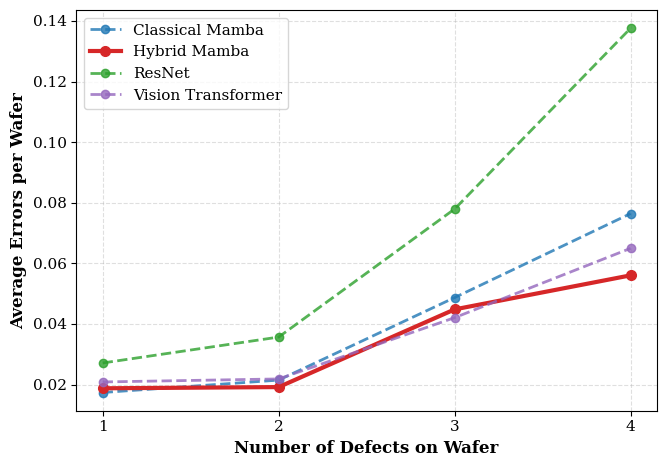

In [93]:
import matplotlib.pyplot as plt
import numpy as np

complexities = [1, 2, 3, 4]

avg_errors = {}

for name, (y_true, _, y_pred) in models.items():
    errs = []

    for k in complexities:
        mask = y_true.sum(axis=1) == k
        if mask.sum() == 0:
            errs.append(np.nan)
            continue

        mistakes = (y_true[mask] != y_pred[mask]).sum(axis=1)
        errs.append(mistakes.mean())

    avg_errors[name] = errs

COLORS = {
    "Classical Mamba": "#1f77b4",
    "Hybrid Mamba": "#d62728",
    "ResNet": "#2ca02c",
    "Vision Transformer": "#9467bd",
}

plt.figure(figsize=(6.8, 4.8))

for name, errs in avg_errors.items():
    if name == "Hybrid Mamba":
        plt.plot(
            complexities, errs,
            marker="o", markersize=7,
            linewidth=3,
            color=COLORS[name],
            label=name
        )
    else:
        plt.plot(
            complexities, errs,
            marker="o", markersize=6,
            linewidth=2,
            linestyle="--",
            alpha=0.8,
            color=COLORS[name],
            label=name
        )

plt.xlabel("Number of Defects on Wafer",
           fontsize=12, fontweight="bold")
plt.ylabel("Average Errors per Wafer",
           fontsize=12, fontweight="bold")

# plt.title("Error Accumulation with Increasing Defect Complexity",fontsize=13, fontweight="bold")

plt.xticks(complexities)
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(frameon=True)
plt.tight_layout()
fname = "error_accumulation_with_defect_complexity.png"
plt.savefig(fname, dpi=300, bbox_inches="tight")
plt.show()


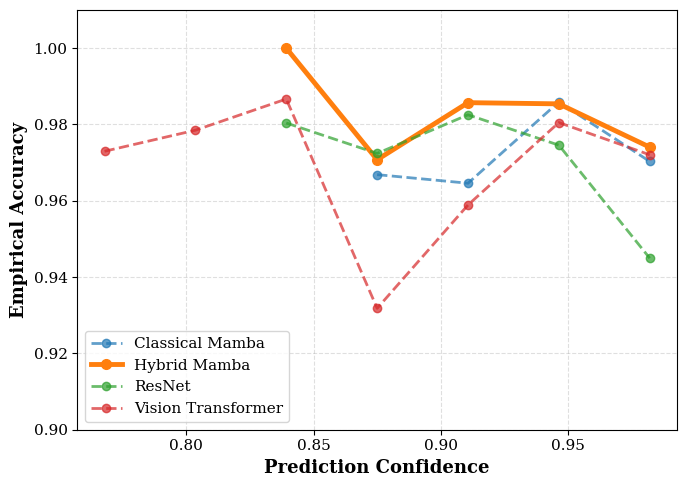

In [94]:
import numpy as np
import matplotlib.pyplot as plt

bins = np.linspace(0.5, 1.0, 15)

plt.figure(figsize=(7,5))

for name, (y_true, y_prob, y_pred) in models.items():

    conf = np.max(y_prob, axis=1)
    correct = (y_true == y_pred).all(axis=1)

    accs = []
    centers = []

    for i in range(len(bins)-1):
        mask = (conf >= bins[i]) & (conf < bins[i+1])

        if mask.sum() < 30:
            continue

        accs.append(correct[mask].mean())
        centers.append((bins[i] + bins[i+1]) / 2)

    if name == "Hybrid Mamba":
        plt.plot(
            centers, accs, marker="o",
            linewidth=3.5, markersize=7,
            label=name
        )
    else:
        plt.plot(
            centers, accs, "--", marker="o",
            alpha=0.7, linewidth=2,
            label=name
        )

plt.xlabel("Prediction Confidence", fontsize=13, fontweight="bold")
plt.ylabel("Empirical Accuracy", fontsize=13, fontweight="bold")
#plt.title("Accuracy vs Confidence (Decision Trustworthiness)",fontsize=14, fontweight="bold")

plt.ylim(0.9, 1.01)
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(frameon=True)
plt.tight_layout()
fname = "accuracy_vs_confidence_decision_trustworthiness.png"
plt.savefig(fname, dpi=300, bbox_inches="tight")
plt.show()


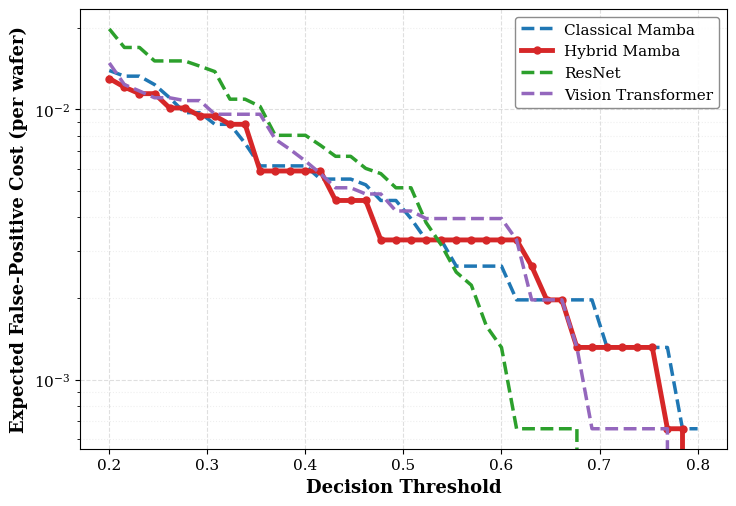

In [95]:
import numpy as np
import matplotlib.pyplot as plt

COST = {
    "Near_Full": 5.0,
    "Random": 2.0,
}

STYLE = {
    "Classical Mamba": dict(color="#1f77b4", linestyle="--", linewidth=2.5),
    "Hybrid Mamba": dict(color="#d62728", linestyle="-",  linewidth=3.5),  # highlight
    "ResNet": dict(color="#2ca02c", linestyle="--", linewidth=2.5),
    "Vision Transformer": dict(color="#9467bd", linestyle="--", linewidth=2.5),
}

ts = np.linspace(0.2, 0.8, 40)

plt.figure(figsize=(7.5, 5.2))

for name, (y_true, y_prob, _) in models.items():
    costs = []

    for t in ts:
        y_p = (y_prob >= t).astype(int)
        c = 0.0
        for cls, w in COST.items():
            i = CLASSES.index(cls)
            fp = ((y_true[:, i] == 0) & (y_p[:, i] == 1)).sum()
            c += w * fp

        costs.append(c / y_true.shape[0])

    plt.plot(
        ts,
        costs,
        label=name,
        marker="o" if name == "Hybrid Mamba" else None,
        markersize=5 if name == "Hybrid Mamba" else 0,
        **STYLE[name]
    )

# ---- SCALE ----
plt.yscale("log")

# ---- AXES ----
plt.xlabel("Decision Threshold", fontsize=13, fontweight="bold")
plt.ylabel("Expected False-Positive Cost (per wafer)", fontsize=13, fontweight="bold")


#    "Operational Risk Curve (Lower is Better)",

# ---- GRID ----
plt.grid(True, which="major", linestyle="--", alpha=0.4)
plt.grid(True, which="minor", linestyle=":", alpha=0.2)

# ---- LEGEND ----
plt.legend(
    fontsize=11,
    frameon=True,
    fancybox=True,
    framealpha=0.9,
    edgecolor="gray"
)

# ---- TICKS ----
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
fname = "operational_risk_curve.png"
plt.savefig(fname, dpi=300, bbox_inches="tight")
plt.show()
